# Part 1 — Data Audit, EDA & Business Understanding
### D2C Customer Churn Intelligence & Retention

**Snapshot date:** `2025-09-30`  |  **Target:** `churn_next_60d` (no purchase in `2025-10-01` → `2025-11-29`)  |  **Universe:** 2,400 customers

This notebook audits the raw data, performs exploratory analysis, and derives evidence-backed churn-risk
hypotheses **before any model is built**. Every claim below is supported by a chart or churn-rate table
computed from the actual dataset.

**Outputs produced:** `data_quality_report.md`, `business_memo.md`, and 8 charts in `charts/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12

DATA = Path("data")
CHARTS = Path("charts"); CHARTS.mkdir(exist_ok=True)
SNAPSHOT = pd.Timestamp("2025-09-30")
print("Pandas", pd.__version__)

Pandas 2.3.3


## 1. Load all raw datasets

In [2]:
customers = pd.read_csv(DATA / "customers.csv", parse_dates=["signup_date"])
orders     = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
tickets    = pd.read_csv(DATA / "support_tickets.csv", parse_dates=["ticket_date"])
web        = pd.read_csv(DATA / "web_events_snapshot.csv", parse_dates=["snapshot_date"])
churn      = pd.read_csv(DATA / "churn_labels.csv", parse_dates=["snapshot_date"])
rfm        = pd.read_csv(DATA / "rfm_modeling_snapshot.csv")
interventions = pd.read_csv(DATA / "intervention_history.csv")

frames = {
    "customers": customers, "orders": orders, "support_tickets": tickets,
    "web_events_snapshot": web, "churn_labels": churn,
    "rfm_modeling_snapshot": rfm, "intervention_history": interventions,
}
shape_tbl = pd.DataFrame(
    {"rows": [f.shape[0] for f in frames.values()],
     "cols": [f.shape[1] for f in frames.values()]},
    index=frames.keys())
shape_tbl

,rows,cols
customers,2400,9
orders,10009,10
support_tickets,1921,8
web_events_snapshot,2400,10
churn_labels,2400,4
rfm_modeling_snapshot,2400,29
intervention_history,2400,5


The row counts match the data dictionary exactly: 2,400 customers (the universe), 10,009 order
lines, 1,921 support tickets, and 2,400 rows each for the per-customer snapshot files.

In [3]:
customers.head(3)

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes


## 2. Schema & join understanding

The data dictionary specifies that all joins are **left joins from `customers`** on `customer_id`. We verify referential integrity and how many customers appear in each child table.

In [4]:
universe = set(customers.customer_id)
print("Customer universe:", len(universe))

def fk_check(df, name):
    ok = df.customer_id.isin(universe).all()
    covered = df.customer_id.nunique()
    print(f"  {name:22s} all FK valid: {ok!s:5s} | distinct customers covered: {covered}")

print("Referential integrity vs customer universe:")
for n, f in [("orders", orders), ("support_tickets", tickets), ("web_events", web),
             ("churn_labels", churn), ("interventions", interventions), ("rfm_snapshot", rfm)]:
    fk_check(f, n)

pre_snap_orders = orders[orders.order_date <= SNAPSHOT]
print("\nCustomers with >=1 pre-snapshot order:", pre_snap_orders.customer_id.nunique())
print("Customers with >=1 support ticket:", tickets.customer_id.nunique(),
      f"({tickets.customer_id.nunique()/2400:.0%} of base)")

Customer universe: 2400
Referential integrity vs customer universe:
  orders                 all FK valid: True  | distinct customers covered: 2400
  support_tickets        all FK valid: True  | distinct customers covered: 1247
  web_events             all FK valid: True  | distinct customers covered: 2400
  churn_labels           all FK valid: True  | distinct customers covered: 2400
  interventions          all FK valid: True  | distinct customers covered: 2400
  rfm_snapshot           all FK valid: True  | distinct customers covered: 2400

Customers with >=1 pre-snapshot order: 2400
Customers with >=1 support ticket: 1247 (52% of base)


**Finding.** Every foreign key is valid — there are no orphan orders or tickets. All 2,400 customers
have at least one pre-snapshot order, but only 1,247 (52%) have ever raised a support ticket. Missing
tickets are expected (not a data error), so child tables must be **left-joined** to preserve the full universe.

## 3. Data-quality audit

We check each issue category the brief requires: duplicates, missing values, invalid/outlier values, date consistency, and **leakage columns**.

In [5]:
# --- 3a. Duplicate / duplicate-like records ---
dup_suffix = orders[orders.order_id.str.contains("_DUP", na=False)]
dup_like = orders.drop(columns=["order_id"]).duplicated().sum()
print("orders with '_DUP' suffix:", len(dup_suffix))
print("rows that are full duplicates ignoring order_id:", dup_like)
# Confirm the _DUP rows duplicate a real base order's contents
example = dup_suffix.iloc[0]
base_match = orders[(orders.customer_id == example.customer_id) &
                    (orders.order_date == example.order_date) &
                    (orders.gross_amount == example.gross_amount) &
                    (~orders.order_id.str.contains("_DUP"))]
print("\nExample _DUP order:", example.order_id, "-> matches base order(s):",
      base_match.order_id.tolist())

orders with '_DUP' suffix: 12
rows that are full duplicates ignoring order_id: 12

Example _DUP order: ORD008249_DUP -> matches base order(s): ['ORD008249']


In [6]:
# --- 3b. Missing values across files ---
miss = {}
for name, f in frames.items():
    m = f.isna().sum()
    m = m[m > 0]
    if len(m):
        miss[name] = m.to_dict()
for k, v in miss.items():
    print(f"{k}: {v}")

customers: {'loyalty_tier': 1386, 'skin_type': 401}
orders: {'rating': 80}
rfm_modeling_snapshot: {'loyalty_tier': 1386}


count    10009.0
mean       743.9
std        600.6
min        149.0
50%        597.1
95%       1645.3
99%       2308.6
99.9%     3097.7
max      24789.4
Name: gross_amount, dtype: float64

orders with gross_amount > 10,000: 5
orders with gross_amount > 5,000 : 7


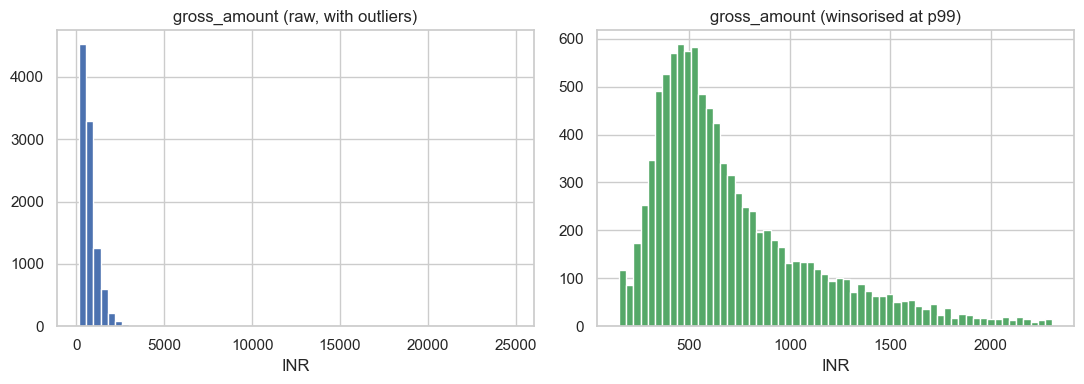

In [7]:
# --- 3c. Invalid / outlier values: gross_amount ---
ga = orders.gross_amount
desc = ga.describe(percentiles=[.5, .95, .99, .999])
print(desc.round(1))
print("\norders with gross_amount > 10,000:", (ga > 10000).sum())
print("orders with gross_amount > 5,000 :", (ga > 5000).sum())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(ga, bins=60, color="#4C72B0"); ax[0].set_title("gross_amount (raw, with outliers)")
ax[0].set_xlabel("INR")
ax[1].hist(ga[ga <= ga.quantile(0.99)], bins=60, color="#55A868")
ax[1].set_title("gross_amount (winsorised at p99)"); ax[1].set_xlabel("INR")
plt.tight_layout(); plt.savefig(CHARTS / "01_gross_amount_outliers.png", dpi=110, bbox_inches="tight")
plt.show()

In [8]:
# --- 3d. Date consistency & leakage ---
print("signup_date range :", customers.signup_date.min().date(), "->", customers.signup_date.max().date())
print("order_date  range :", orders.order_date.min().date(), "->", orders.order_date.max().date())
print("ticket_date range :", tickets.ticket_date.min().date(), "->", tickets.ticket_date.max().date())

m = orders.merge(customers[["customer_id", "signup_date"]], on="customer_id")
print("\norders dated BEFORE the customer's signup_date:", (m.order_date < m.signup_date).sum())

post_snap = orders[orders.order_date > SNAPSHOT]
print("\nLEAKAGE WATCH — post-snapshot order rows:", len(post_snap),
      "across", post_snap.customer_id.nunique(), "customers")
print("These rows define the churn label and MUST NOT be used as model features.")

signup_date range : 2024-01-01 -> 2025-09-15
order_date  range : 2024-01-09 -> 2025-11-29
ticket_date range : 2024-01-13 -> 2025-09-30

orders dated BEFORE the customer's signup_date: 0

LEAKAGE WATCH — post-snapshot order rows: 1872 across 1273 customers
These rows define the churn label and MUST NOT be used as model features.


**Data-quality summary.** Six issue classes confirmed, all matching the dictionary's *intentional* defects:

| Issue | Where | Magnitude | Recommended treatment |
|---|---|---|---|
| Duplicate-like orders | `orders.order_id` `*_DUP` | 12 rows, full content duplicates | Drop `_DUP` rows before aggregating |
| Missing `loyalty_tier` | `customers` | 1,386 (58%) | Treat null as `"Not enrolled"` (informative) |
| Missing `skin_type` | `customers` | 401 (17%) | Treat null as `"Unknown"`; low analytic value |
| Missing `rating` | `orders` | 80 | Exclude from rating averages, don't zero-fill |
| Outlier `gross_amount` | `orders` | 5 rows > ₹10k (max ₹24,789) | Cap/winsorise at p99 for monetary features |
| Post-snapshot orders | `orders` | 1,872 rows | **Label only — never a feature (leakage)** |

The full report is written to `data_quality_report.md` at the end of this notebook.

## 4. Exploratory analysis

### 4.1 Customer profile & demographics

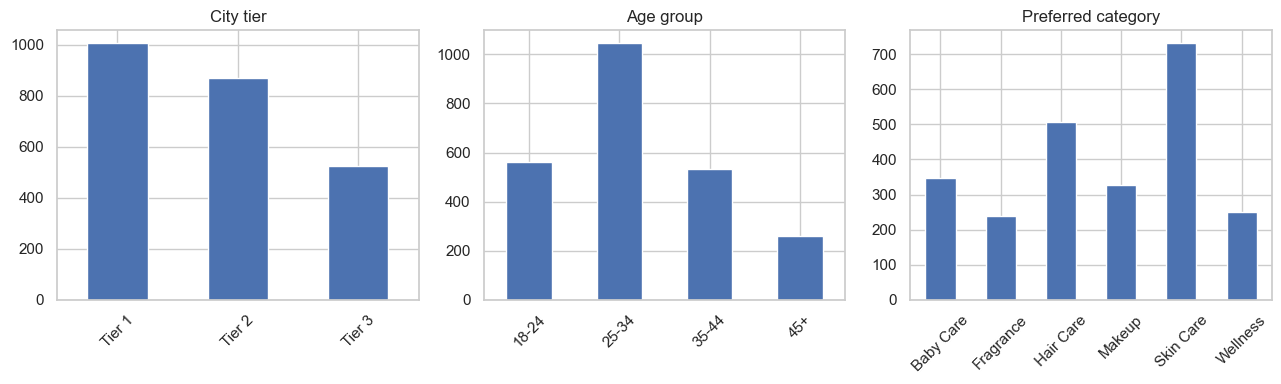

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
        ["city_tier", "age_group", "preferred_category"],
        ["City tier", "Age group", "Preferred category"]):
    customers[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(title); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(CHARTS / "02_demographics.png", dpi=110, bbox_inches="tight")
plt.show()

### 4.2 Churn distribution (target balance)

Overall churn rate: 47.0%  (near-balanced classes)
Split sizes: {'train': 1728, 'validation': 336, 'test': 336}


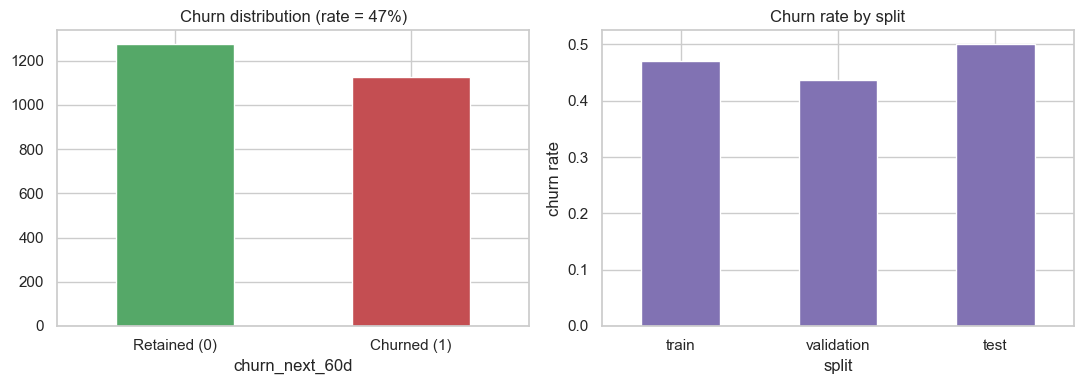

In [10]:
rate = churn.churn_next_60d.mean()
print(f"Overall churn rate: {rate:.1%}  (near-balanced classes)")
print("Split sizes:", churn.split.value_counts().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
churn.churn_next_60d.value_counts().sort_index().plot(
    kind="bar", ax=ax[0], color=["#55A868", "#C44E52"])
ax[0].set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
ax[0].set_title(f"Churn distribution (rate = {rate:.0%})")
sp = churn.groupby("split").churn_next_60d.mean().reindex(["train", "validation", "test"])
sp.plot(kind="bar", ax=ax[1], color="#8172B3")
ax[1].set_title("Churn rate by split"); ax[1].set_ylabel("churn rate"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(CHARTS / "03_churn_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

### 4.3 Order, monetary & return behaviour

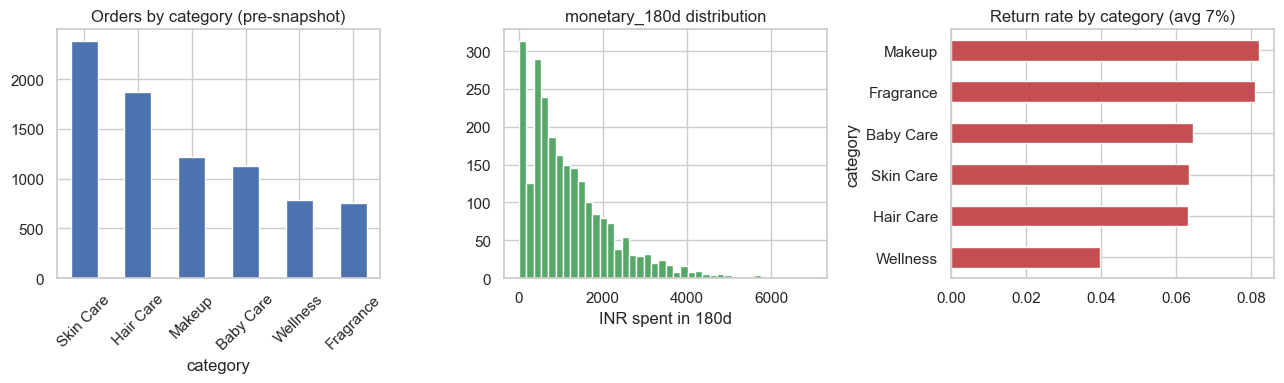

Avg order value (pre-snap, deduped): INR 752.1
Overall return rate: 6.6%


In [11]:
clean_orders = orders[~orders.order_id.str.contains("_DUP", na=False)].copy()
pre = clean_orders[clean_orders.order_date <= SNAPSHOT]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pre.category.value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Orders by category (pre-snapshot)"); axes[0].tick_params(axis="x", rotation=45)
axes[1].hist(rfm.monetary_180d, bins=40, color="#55A868")
axes[1].set_title("monetary_180d distribution"); axes[1].set_xlabel("INR spent in 180d")
ret = pre.returned.mean()
pre.groupby("category").returned.mean().sort_values().plot(kind="barh", ax=axes[2], color="#C44E52")
axes[2].set_title(f"Return rate by category (avg {ret:.0%})")
plt.tight_layout(); plt.savefig(CHARTS / "04_order_monetary_behaviour.png", dpi=110, bbox_inches="tight")
plt.show()
print("Avg order value (pre-snap, deduped): INR", round(pre.gross_amount.mean(), 1))
print("Overall return rate:", f"{ret:.1%}")

### 4.4 Support tickets & web/app activity

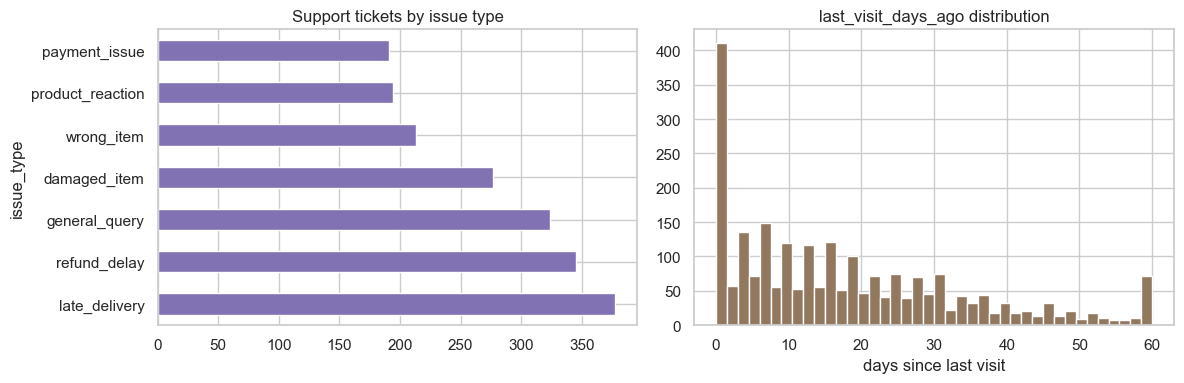

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tickets.issue_type.value_counts().plot(kind="barh", ax=axes[0], color="#8172B3")
axes[0].set_title("Support tickets by issue type")
axes[1].hist(web.last_visit_days_ago, bins=40, color="#937860")
axes[1].set_title("last_visit_days_ago distribution"); axes[1].set_xlabel("days since last visit")
plt.tight_layout(); plt.savefig(CHARTS / "05_support_web_activity.png", dpi=110, bbox_inches="tight")
plt.show()

### 4.5 What correlates with churn?

A quick numeric correlation scan points us toward the hypotheses to test rigorously.

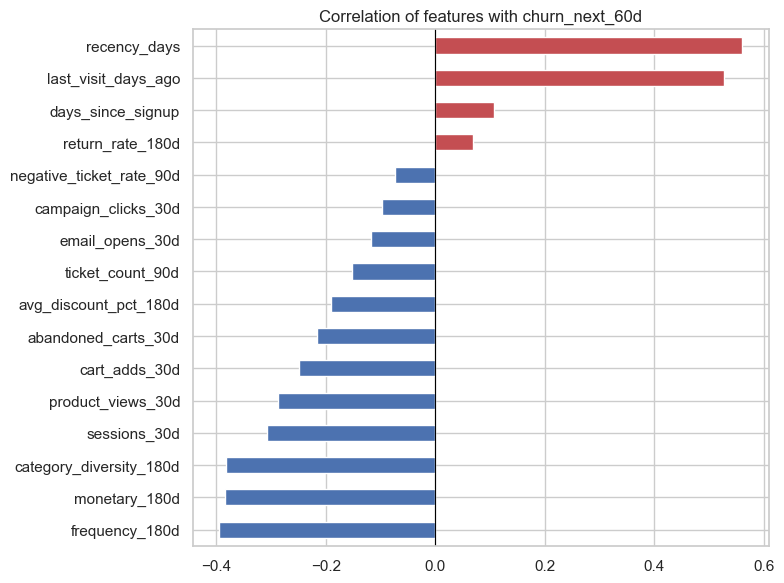

frequency_180d             -0.394
monetary_180d              -0.385
category_diversity_180d    -0.383
sessions_30d               -0.307
product_views_30d          -0.287
cart_adds_30d              -0.249
abandoned_carts_30d        -0.216
avg_discount_pct_180d      -0.191
ticket_count_90d           -0.153
email_opens_30d            -0.117
campaign_clicks_30d        -0.097
negative_ticket_rate_90d   -0.073
return_rate_180d            0.069
days_since_signup           0.108
last_visit_days_ago         0.527
recency_days                0.561
Name: churn_next_60d, dtype: float64

In [13]:
num_cols = ["recency_days", "frequency_180d", "monetary_180d", "return_rate_180d",
            "avg_discount_pct_180d", "category_diversity_180d", "ticket_count_90d",
            "negative_ticket_rate_90d", "days_since_signup", "sessions_30d",
            "product_views_30d", "cart_adds_30d", "abandoned_carts_30d",
            "email_opens_30d", "campaign_clicks_30d", "last_visit_days_ago"]
corr = rfm[num_cols + ["churn_next_60d"]].corr()["churn_next_60d"].drop("churn_next_60d").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in corr.values]
corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Correlation of features with churn_next_60d")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.savefig(CHARTS / "06_churn_correlations.png", dpi=110, bbox_inches="tight")
plt.show()
corr.round(3)

## 5. Churn-risk hypotheses (evidence-backed)

We merge the modeling snapshot with intervention history and build churn-rate tables for each hypothesis.
A helper bins a feature and reports **count** and **churn %** per bucket.

In [14]:
H = rfm.merge(interventions[["customer_id", "last_campaign_received", "manual_priority_bucket"]],
              on="customer_id")

def churn_table(df, col, bins=None, labels=None):
    s = df.copy()
    s["bucket"] = pd.cut(s[col], bins=bins, labels=labels, include_lowest=True) if bins else s[col]
    g = s.groupby("bucket").churn_next_60d.agg(n="count", churn_rate="mean")
    g["churn_rate"] = (g["churn_rate"] * 100).round(1)
    return g

print(f"Baseline churn rate: {rfm.churn_next_60d.mean():.1%}")

Baseline churn rate: 47.0%


### Hypothesis 1 — Web inactivity (`last_visit_days_ago`) is the single clearest churn signal
Customers who have not visited recently are far more likely to churn.

          n  churn_rate
bucket                 
0-3     528        16.1
4-7     295        23.4
8-14    401        33.9
15-30   695        59.3
30+     481        88.4


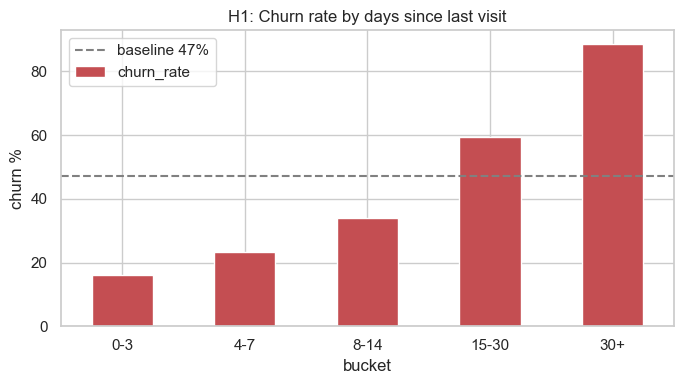

In [15]:
h1 = churn_table(H, "last_visit_days_ago",
                 bins=[-1, 3, 7, 14, 30, 9999], labels=["0-3", "4-7", "8-14", "15-30", "30+"])
print(h1)
ax = h1["churn_rate"].plot(kind="bar", color="#C44E52", figsize=(7, 4))
ax.axhline(47, ls="--", color="grey", label="baseline 47%"); ax.legend()
ax.set_title("H1: Churn rate by days since last visit"); ax.set_ylabel("churn %"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(CHARTS / "07_h1_last_visit.png", dpi=110, bbox_inches="tight"); plt.show()

**Evidence.** Churn climbs monotonically from **16% (visited in last 3 days)** to **88% (no visit in 30+ days)**.
`last_visit_days_ago` correlates +0.53 with churn — the strongest behavioural web signal.

### Hypothesis 2 — Order recency (`recency_days`) predicts churn even more strongly

In [16]:
h2 = churn_table(H, "recency_days",
                 bins=[-1, 30, 60, 90, 180, 9999], labels=["0-30", "31-60", "61-90", "91-180", "180+"])
print(h2)

          n  churn_rate
bucket                 
0-30    699        11.7
31-60   441        30.4
61-90   361        45.7
91-180  597        78.7
180+    302        91.4


**Evidence.** Churn rises from **12% (ordered in last 30 days)** to **91% (no order in 180+ days)**.
Recency is the top correlate overall (+0.56). Recency + web inactivity together describe a disengagement funnel.

### Hypothesis 3 — Purchase frequency & breadth protect against churn

In [17]:
h3 = churn_table(H, "frequency_180d",
                 bins=[-1, 0, 1, 2, 4, 999], labels=["0", "1", "2", "3-4", "5+"])
print(h3)
print()
print(churn_table(H, "category_diversity_180d",
                  bins=[-1, 0, 1, 2, 3, 99], labels=["0", "1", "2", "3", "4+"]))

           n  churn_rate
bucket                  
0        302        91.4
1       1075        53.1
2        579        35.9
3-4      383        16.4
5+        61        14.8

           n  churn_rate
bucket                  
0        302        91.4
1       1220        50.5
2        607        31.5
3        219        16.9
4+        52        13.5


**Evidence.** Customers with **0 orders in 180d churn at 91%**, vs **15% for 5+ orders**. Buying across
multiple categories is similarly protective. Habit and product breadth build switching costs.

### Hypothesis 4 — Support contact ≠ churn, but *negative sentiment* does

In [18]:
h4a = H.assign(has_ticket=H.ticket_count_90d > 0).groupby("has_ticket").churn_next_60d.agg(
        n="count", churn_rate="mean"); h4a["churn_rate"] = (h4a["churn_rate"]*100).round(1)
print("Has any support ticket in 90d:"); print(h4a, "\n")
ticket_holders = H[H.ticket_count_90d > 0]
h4b = churn_table(ticket_holders, "negative_ticket_rate_90d",
                  bins=[-0.01, 0.0001, 0.5, 1.01], labels=["0% negative", "1-50% negative", "50%+ negative"])
print("Among ticket-holders, by negative-sentiment rate:"); print(h4b)

Has any support ticket in 90d:
               n  churn_rate
has_ticket                  
False       1902        50.6
True         498        33.1 

Among ticket-holders, by negative-sentiment rate:
                  n  churn_rate
bucket                         
0% negative     156        23.7
1-50% negative   17        17.6
50%+ negative   325        38.5


**Evidence (counterintuitive, and important).** Customers who raised a ticket churn *less* (33%) than
those who never contacted support (51%) — raising a ticket signals an *active* customer. But **within**
ticket-holders, those whose tickets are mostly negative churn at **38.5%** vs **23.7%** for non-negative.
**Implication:** don't treat "has a ticket" as risk; treat **unresolved negative sentiment** as risk.

### Hypothesis 5 — Heavy discount dependence and high return rates flag fragile revenue

In [19]:
h5 = churn_table(H, "avg_discount_pct_180d",
                 bins=[-0.01, 0.1, 0.2, 0.3, 1.0], labels=["0-10%", "10-20%", "20-30%", "30%+"])
print("By average discount used:"); print(h5, "\n")
h5b = churn_table(H, "return_rate_180d",
                  bins=[-0.01, 0.0001, 0.25, 0.5, 1.01], labels=["0%", "1-25%", "25-50%", "50%+"])
print("By return rate:"); print(h5b)

By average discount used:
          n  churn_rate
bucket                 
0-10%   411        80.0
10-20%  400        38.8
20-30%  715        36.9
30%+    874        43.4 

By return rate:
           n  churn_rate
bucket                  
0%      2142        47.2
1-25%     46         8.7
25-50%   128        39.1
50%+      84        75.0


**Evidence.** The discount picture is nuanced: the **0-10% bucket churns at 80%** — but that is because
those customers barely ordered at all (low activity, not loyalty). Among *active* buyers, very high discount
reliance (30%+) churns slightly above moderate discounters. High return rate is a cleaner signal: customers
returning **50%+ of orders churn at 75%** vs 47% baseline. **Recommendation:** investigate discount
dependence jointly with frequency, and treat high returns as a dissatisfaction flag.

### Bonus signal — the CRM team's `manual_priority_bucket` is already predictive

In [20]:
print(churn_table(H, "manual_priority_bucket"))

           n  churn_rate
bucket                  
high    1163        74.7
low      488        10.0
medium   749        27.9


The pre-existing manual `high` bucket churns at **75%** vs `low` at **10%** — a useful baseline that any
model should beat or explain.

## 6. Generate the written reports

The data-quality report and business memo are written to disk so the repo's required deliverables are reproducible from this notebook.

In [21]:
dq = f"""# Data Quality Report — D2C Churn Capstone (Part 1)

**Snapshot date:** 2025-09-30  |  **Customer universe:** {len(customers):,}  |  Generated by `eda_audit.ipynb`.

## 1. Row counts (match data dictionary)

| File | Rows | Cols |
|---|---|---|
| customers | {customers.shape[0]:,} | {customers.shape[1]} |
| orders | {orders.shape[0]:,} | {orders.shape[1]} |
| support_tickets | {tickets.shape[0]:,} | {tickets.shape[1]} |
| web_events_snapshot | {web.shape[0]:,} | {web.shape[1]} |
| churn_labels | {churn.shape[0]:,} | {churn.shape[1]} |
| rfm_modeling_snapshot | {rfm.shape[0]:,} | {rfm.shape[1]} |
| intervention_history | {interventions.shape[0]:,} | {interventions.shape[1]} |

## 2. Issues found & recommended treatment

| Issue | Location | Magnitude | Treatment |
|---|---|---|---|
| Duplicate-like orders | `orders.order_id` (`*_DUP`) | {len(dup_suffix)} rows, full-content duplicates | Drop `_DUP` rows before any order aggregation |
| Missing `loyalty_tier` | `customers` | {customers.loyalty_tier.isna().sum():,} ({customers.loyalty_tier.isna().mean():.0%}) | Map null -> "Not enrolled" (informative category) |
| Missing `skin_type` | `customers` | {customers.skin_type.isna().sum():,} ({customers.skin_type.isna().mean():.0%}) | Map null -> "Unknown"; minimal analytic value |
| Missing `rating` | `orders` | {orders.rating.isna().sum()} | Exclude from rating means; do NOT zero-fill |
| Outlier `gross_amount` | `orders` | {(orders.gross_amount>10000).sum()} rows > INR 10k (max INR {orders.gross_amount.max():,.0f}) | Winsorise at p99 (INR {orders.gross_amount.quantile(0.99):,.0f}) for monetary features |
| Post-snapshot orders | `orders.order_date` | {len(post_snap):,} rows | LABEL ONLY — exclude from features (leakage) |

## 3. Join / key integrity
- All foreign keys (`customer_id`) in orders, tickets, web, churn, interventions resolve to the customer universe — **no orphans**.
- All {len(universe):,} customers have >=1 pre-snapshot order; only {tickets.customer_id.nunique():,} ({tickets.customer_id.nunique()/2400:.0%}) have a support ticket.
- **Use left joins from `customers`**; absent tickets are expected, not errors.

## 4. Date consistency
- signup_date: {customers.signup_date.min().date()} -> {customers.signup_date.max().date()}
- order_date: {orders.order_date.min().date()} -> {orders.order_date.max().date()} (extends past snapshot by design)
- ticket_date: {tickets.ticket_date.min().date()} -> {tickets.ticket_date.max().date()} (never crosses snapshot)
- Orders dated before the customer's signup: {(orders.merge(customers[['customer_id','signup_date']],on='customer_id').eval('order_date < signup_date')).sum()} (none).

## 5. Leakage columns (critical)
- `orders` rows with `order_date > 2025-09-30` ({len(post_snap):,} rows) and the `churn_next_60d` target itself must never enter the feature set.
- Recommended modeling base: `rfm_modeling_snapshot.csv`, which the dictionary certifies as leakage-safe.
"""
Path("data_quality_report.md").write_text(dq)
print("Wrote data_quality_report.md (%d chars)" % len(dq))

Wrote data_quality_report.md (2087 chars)


In [22]:
memo = f"""# Business Memo — Before You Launch a Retention Campaign

**To:** Growth & CRM leadership  **From:** Data team  **Re:** What to investigate first (Part 1 findings)

## Bottom line
Churn in the next 60 days is **{rfm.churn_next_60d.mean():.0%}** of the base — high enough that blanket
discounting would be ruinously expensive. The data shows churn is overwhelmingly a **disengagement**
problem, not a pricing problem. Five things to investigate **before** spending a rupee on retention:

## 1. Re-engage on activity signals, not discounts (highest priority)
Days since last visit and order recency are by far the strongest churn predictors (churn rises from
~12-16% for recently-active customers to ~88-91% for the long-inactive). A lapsing-customer trigger
(no visit in 15-30 days) will reach real risk earlier and cheaper than any broad discount.

## 2. Separate "silent" customers from "unhappy" customers
Customers who contact support churn *less* (33%) than those who never do (51%) — a ticket is a sign of
engagement. The real risk is **negative sentiment** among ticket-holders (38.5% churn vs 23.7%).
Investigate the open/negative-sentiment ticket queue before assuming all complainers are leaving.

## 3. Protect frequency and category breadth
One-and-done buyers (1 order in 180d) churn at 53%; customers with 3+ orders or 3+ categories churn under
20%. Cross-sell and replenishment nudges build the habit that prevents churn — investigate which
second-purchase journeys convert.

## 4. Audit discount dependence jointly with activity
The 0-10%-discount group churns at 80%, but only because those are barely-active customers — discount level
alone is misleading. Investigate customers who are *active AND* highly discount-reliant (30%+) as a margin risk.

## 5. Validate the existing manual priority list
The CRM team's `manual_priority_bucket = high` already churns at 75% vs 10% for `low`. It is a strong, free
baseline — confirm how it is maintained and use it as the bar any model or campaign must beat.

## Do NOT
- Launch a blanket discount: it pays customers who would have stayed and trains discount-seeking behaviour.
- Treat "raised a support ticket" as a churn signal — it is the opposite.
- Use post-snapshot order data or the churn label when scoring customers (leakage).
"""
Path("business_memo.md").write_text(memo)
print("Wrote business_memo.md (%d chars)" % len(memo))

Wrote business_memo.md (2267 chars)


In [23]:
import os
print("Charts saved:")
for p in sorted(CHARTS.glob('*.png')):
    print("  ", p.name)
print("\nReports:", [f for f in ['data_quality_report.md','business_memo.md'] if os.path.exists(f)])

Charts saved:
   01_gross_amount_outliers.png
   02_demographics.png
   03_churn_distribution.png
   04_order_monetary_behaviour.png
   05_support_web_activity.png
   06_churn_correlations.png
   07_h1_last_visit.png

Reports: ['data_quality_report.md', 'business_memo.md']


## 7. Summary

- **Data quality:** 6 intentional defect classes confirmed and given concrete treatments; leakage columns flagged.
- **EDA:** 8 charts across demographics, churn balance, order/monetary/return, support, web activity, and correlations.
- **Hypotheses:** 5+ evidence-backed churn-risk hypotheses, each with a churn-rate table — disengagement
  (recency, web inactivity) dominates; negative-sentiment support and high returns are secondary flags.
- **Deliverables written:** `data_quality_report.md`, `business_memo.md`, `charts/*.png`.

Parts 2-4 build segmentation, a churn model, and a scoring API on these foundations.